In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf 

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True



In [5]:
import sys
import os

sys.path.insert(0, os.path.abspath('..'))

print('Path set. Python will now look in:', os.path.abspath('..'))

Path set. Python will now look in: /home/mine/10 Academy/news-sentiment-analysis


In [6]:
# ─────────────────────────────────────────────────────────────
# Import our functions from src/
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

from src.data_loader import load_data, remove_nulls
from src.analysis    import compute_sma, get_daily_return

print('Functions imported successfully!')
print()

Functions imported successfully!



In [7]:
aapl_df = load_data('../Data/yfinance_data/AAPL.csv')
aapl_df.head()


Loaded 3774 rows from ../Data/yfinance_data/AAPL.csv


,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [8]:
amzn_df = load_data('../Data/yfinance_data/AMZN.csv')
amzn_df.head()


Loaded 3774 rows from ../Data/yfinance_data/AMZN.csv


,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,2.718,2.7265,2.5535,2.5675,145928000
2009-01-05,2.703,2.7870,2.6515,2.7865,190196000
2009-01-06,2.868,2.9110,2.6875,2.7275,221602000
2009-01-07,2.810,2.8475,2.7675,2.8145,158854000
2009-01-08,2.858,2.8660,2.7290,2.7495,131558000


In [9]:

goog_df = load_data('../Data/yfinance_data/GOOG.csv')
goog_df.head()



Loaded 3774 rows from ../Data/yfinance_data/GOOG.csv


,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,7.948608,7.960977,7.557264,7.633949,144961322
2009-01-05,8.115089,8.194003,7.792268,7.940692,196293007
2009-01-06,8.263762,8.430492,8.074027,8.237046,257971329
2009-01-07,7.965677,8.185839,7.885034,8.121770,180453860
2009-01-08,8.044340,8.044340,7.850152,7.873406,144567852


In [10]:
meta_df = load_data('../Data/yfinance_data/META.csv')
meta_df.head()


Loaded 2923 rows from ../Data/yfinance_data/META.csv


,Close,High,Low,Open,Volume
Date,,,,,
2012-05-18,37.995762,44.724282,37.767172,41.792356,573576400
2012-05-21,33.821495,36.435382,32.797807,36.306177,168192700
2012-05-22,30.810066,33.384198,30.750434,32.410203,101786600
2012-05-23,31.803938,32.300874,31.167860,31.177799,73600000
2012-05-24,32.827625,33.006523,31.575347,32.748117,50237200


In [11]:

nvda_df = load_data('../Data/yfinance_data/NVDA.csv')
nvda_df.head()

Loaded 3774 rows from ../Data/yfinance_data/NVDA.csv


,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,0.199652,0.201027,0.184294,0.184982,497124000
2009-01-05,0.203319,0.207904,0.195984,0.197360,705736000
2009-01-06,0.210196,0.216156,0.204695,0.209279,657904000
2009-01-07,0.197589,0.205382,0.190483,0.205382,870096000
2009-01-08,0.192546,0.195067,0.180626,0.195067,1014496000


In [12]:
print('Missing values per column AAPL:')
print(aapl_df.isnull().sum())
print()

# Now remove them — one line instead of five
aapl_df = remove_nulls(aapl_df)

Missing values per column AAPL:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Removed 0 row(s). 3774 rows remaining.


In [13]:
print('Missing values per column AMZN:')
print(amzn_df.isnull().sum())
print()

    # Now remove them — one line instead of five
amzn_df = remove_nulls(amzn_df)

Missing values per column AMZN:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Removed 0 row(s). 3774 rows remaining.


In [14]:
print('Missing values per column GOOG:')
print(goog_df.isnull().sum())
print()

# Now remove them — one line instead of five
goog_df = remove_nulls(goog_df)

Missing values per column GOOG:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Removed 0 row(s). 3774 rows remaining.


In [15]:
print('Missing values per column META:')
print(meta_df.isnull().sum())
print()

# Now remove them — one line instead of five
meta_df = remove_nulls(meta_df)

Missing values per column META:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Removed 0 row(s). 2923 rows remaining.


In [16]:
print('Missing values per column NVDA:')
print(nvda_df.isnull().sum())
print()

# Now remove them — one line instead of five
nvda_df = remove_nulls(nvda_df)

Missing values per column NVDA:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Removed 0 row(s). 3774 rows remaining.


In [17]:
aapl_df['SMA_5'] = compute_sma(aapl_df['Close'], window=5)

print('5-day SMA computed. First few values are NaN (not enough history yet):')
aapl_df[['Close', 'SMA_5']].head(8).round(2)

5-day SMA computed. First few values are NaN (not enough history yet):


,Close,SMA_5
Date,,
2009-01-02,2.72,NaN
2009-01-05,2.84,NaN
2009-01-06,2.79,NaN
2009-01-07,2.73,NaN
2009-01-08,2.78,2.77
2009-01-09,2.72,2.77
2009-01-12,2.66,2.74
2009-01-13,2.63,2.70


In [18]:
amzn_df['SMA_5'] = compute_sma(amzn_df['Close'], window=5)

print('5-day SMA computed. First few values are NaN (not enough history yet):')
amzn_df[['Close', 'SMA_5']].head(8).round(2)

5-day SMA computed. First few values are NaN (not enough history yet):


,Close,SMA_5
Date,,
2009-01-02,2.72,NaN
2009-01-05,2.70,NaN
2009-01-06,2.87,NaN
2009-01-07,2.81,NaN
2009-01-08,2.86,2.79
2009-01-09,2.78,2.80
2009-01-12,2.60,2.78
2009-01-13,2.57,2.72


In [19]:
goog_df['SMA_5'] = compute_sma(goog_df['Close'], window=5)

print('5-day SMA computed. First few values are NaN (not enough history yet):')
goog_df[['Close', 'SMA_5']].head(8).round(2)

5-day SMA computed. First few values are NaN (not enough history yet):


,Close,SMA_5
Date,,
2009-01-02,7.95,NaN
2009-01-05,8.12,NaN
2009-01-06,8.26,NaN
2009-01-07,7.97,NaN
2009-01-08,8.04,8.07
2009-01-09,7.79,8.04
2009-01-12,7.74,7.96
2009-01-13,7.78,7.86


In [20]:
meta_df['SMA_5'] = compute_sma(meta_df['Close'], window=5)

print('5-day SMA computed. First few values are NaN (not enough history yet):')
meta_df[['Close', 'SMA_5']].head(8).round(2)

5-day SMA computed. First few values are NaN (not enough history yet):


,Close,SMA_5
Date,,
2012-05-18,38.00,NaN
2012-05-21,33.82,NaN
2012-05-22,30.81,NaN
2012-05-23,31.80,NaN
2012-05-24,32.83,33.45
2012-05-25,31.71,32.20
2012-05-29,28.66,31.16
2012-05-30,28.02,30.61


In [21]:
nvda_df['SMA_5'] = compute_sma(nvda_df['Close'], window=5)

print('5-day SMA computed. First few values are NaN (not enough history yet):')
nvda_df[['Close', 'SMA_5']].head(8).round(2)

5-day SMA computed. First few values are NaN (not enough history yet):


,Close,SMA_5
Date,,
2009-01-02,0.20,NaN
2009-01-05,0.20,NaN
2009-01-06,0.21,NaN
2009-01-07,0.20,NaN
2009-01-08,0.19,0.20
2009-01-09,0.18,0.20
2009-01-12,0.17,0.19
2009-01-13,0.18,0.18


In [22]:
# Step 4: Calculate daily return
# Formula: (today price - yesterday price) / yesterday price * 100
aapl_df['Daily_Return'] = get_daily_return(aapl_df['Close'])

print('Daily return calculated. Positive = price went up. Negative = price went down.')
aapl_df[['Close', 'Daily_Return']].round(2).head(8)

Daily return calculated. Positive = price went up. Negative = price went down.


,Close,Daily_Return
Date,,
2009-01-02,2.72,NaN
2009-01-05,2.84,4.22
2009-01-06,2.79,-1.65
2009-01-07,2.73,-2.16
2009-01-08,2.78,1.86
2009-01-09,2.72,-2.29
2009-01-12,2.66,-2.12
2009-01-13,2.63,-1.07


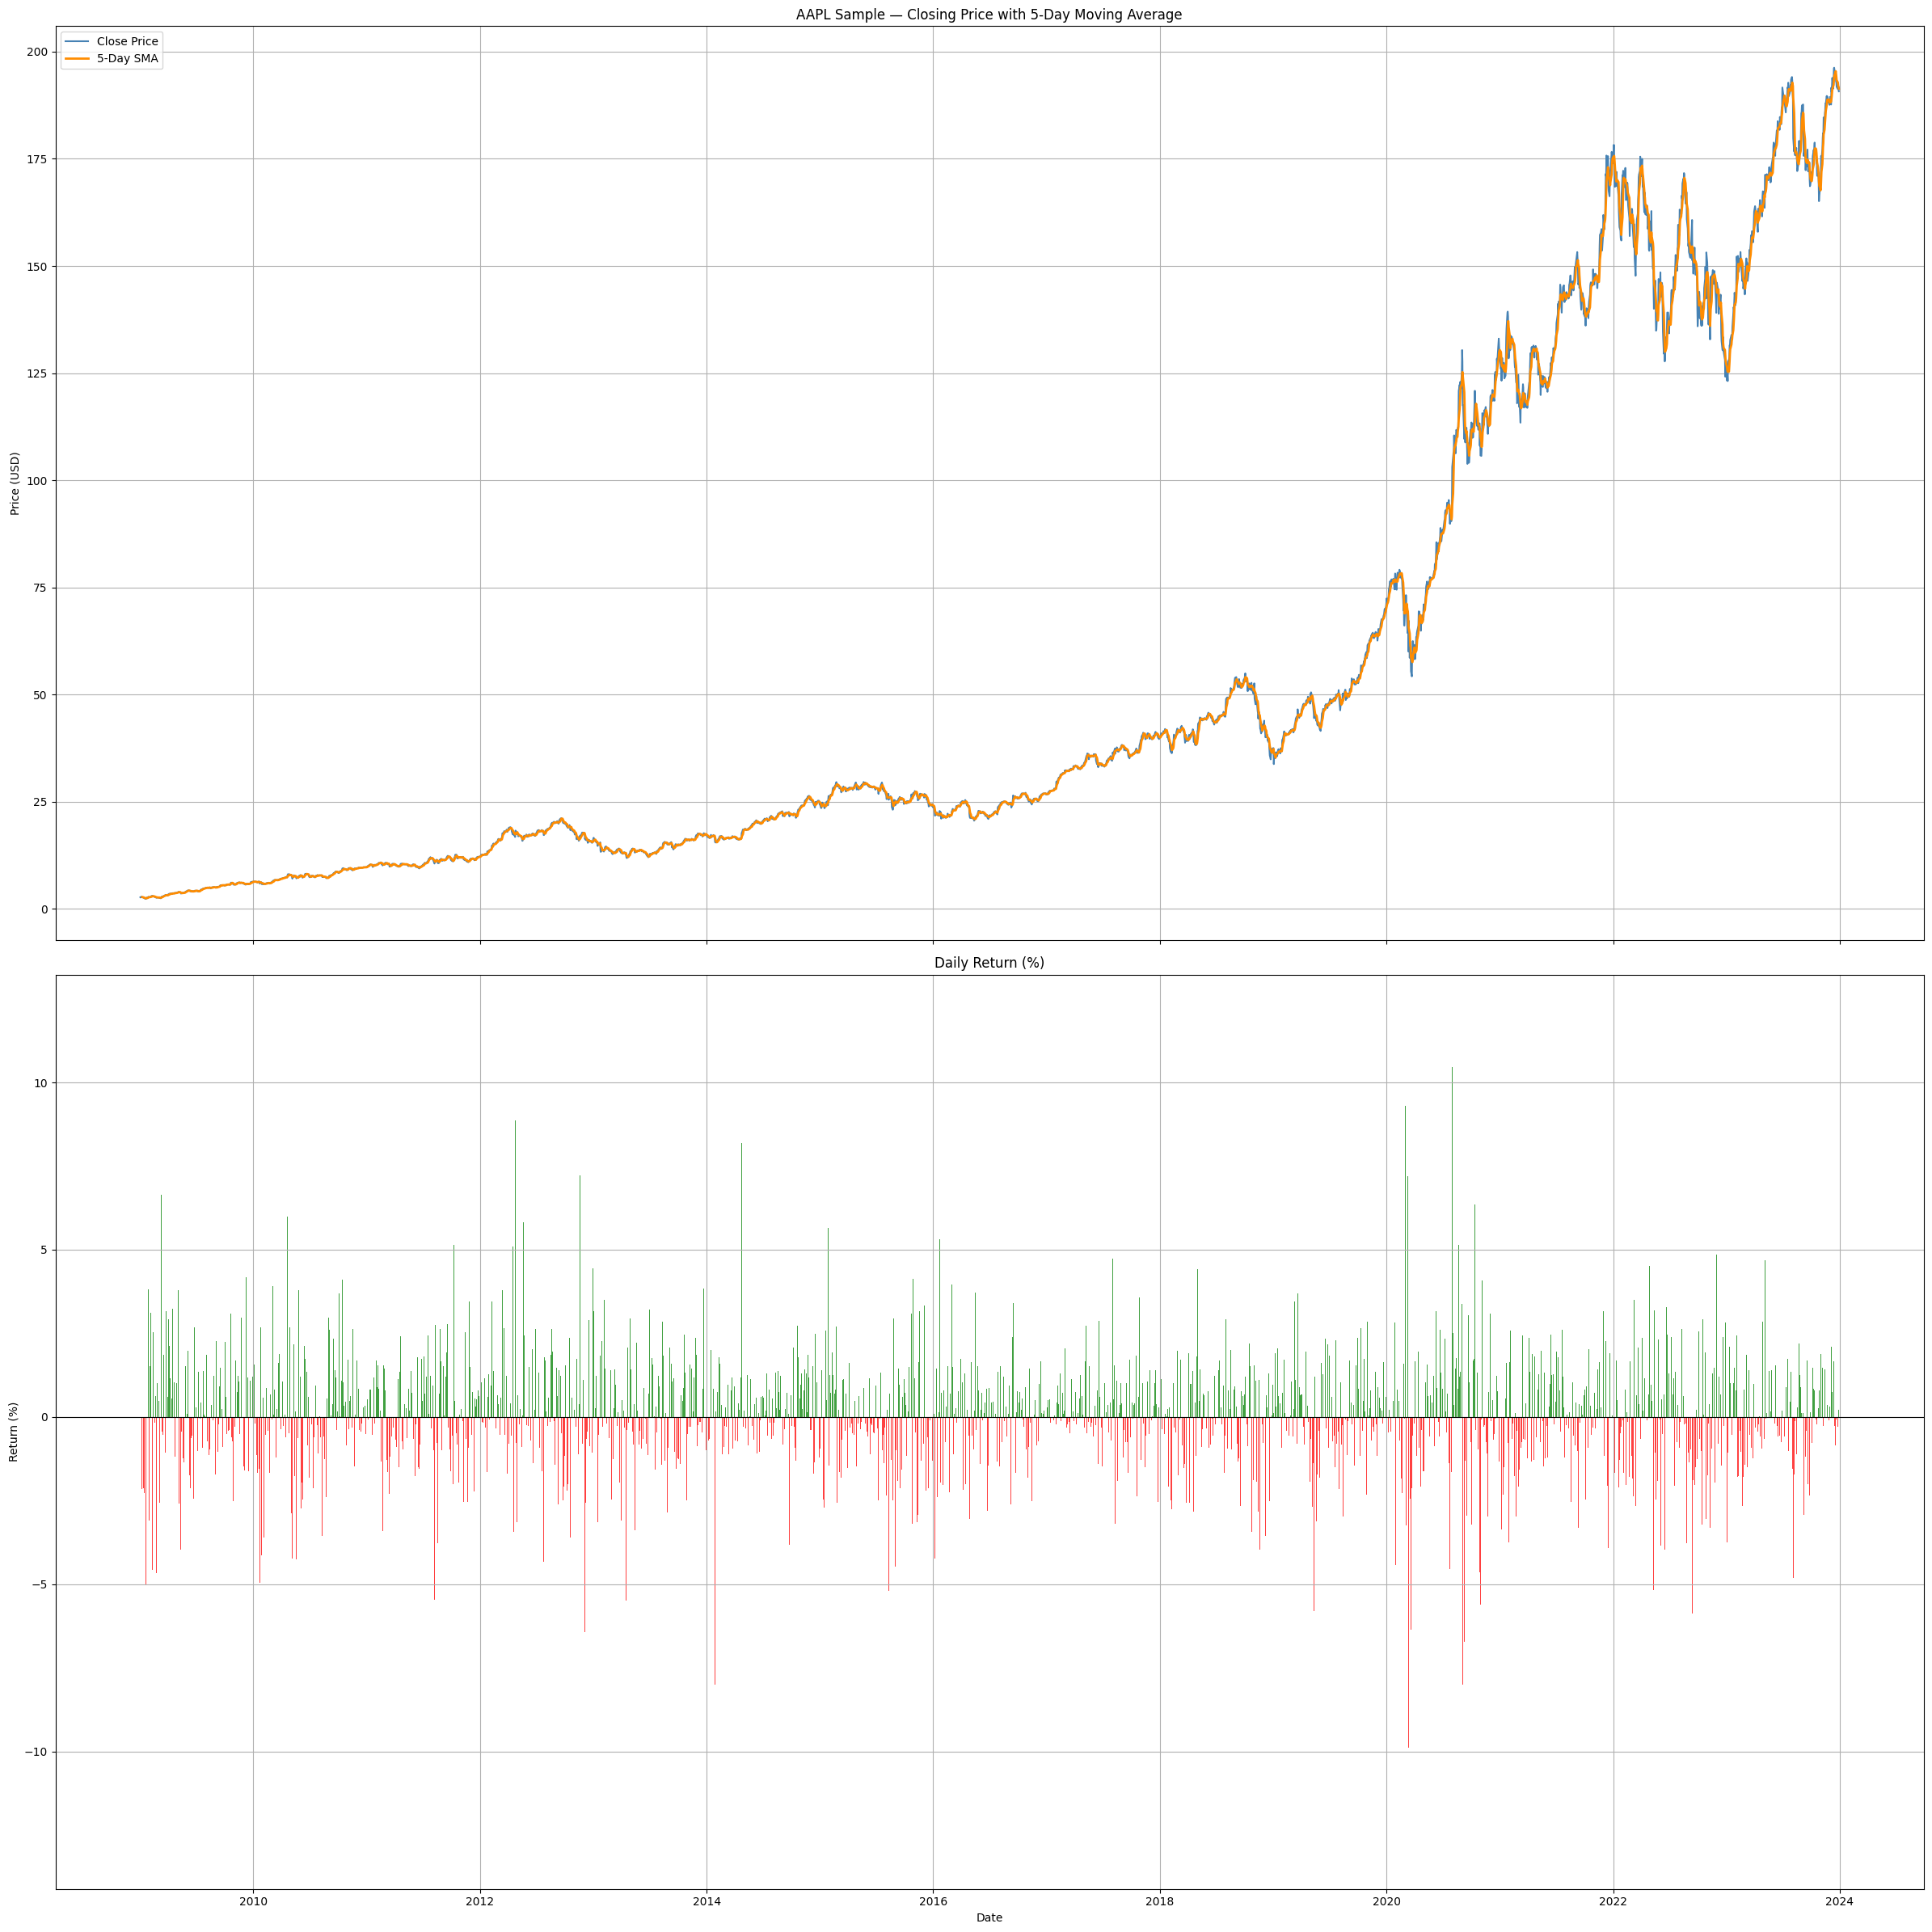

In [23]:
# Step 5: Visualise the result
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(24, 24), sharex=True)

# Price + moving average
ax1.plot(aapl_df.index, aapl_df['Close'],  label='Close Price', color='steelblue', linewidth=1.5)
ax1.plot(aapl_df.index, aapl_df['SMA_5'],  label='5-Day SMA',   color='darkorange', linewidth=2)
ax1.set_title('AAPL Sample — Closing Price with 5-Day Moving Average')
ax1.set_ylabel('Price (USD)')
ax1.legend()

# Daily return (green = positive day, red = negative day)
colors = ['green' if r >= 0 else 'red' for r in aapl_df['Daily_Return'].fillna(0)]
ax2.bar(aapl_df.index, aapl_df['Daily_Return'], color=colors, alpha=0.75, width=1)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('Daily Return (%)')
ax2.set_ylabel('Return (%)')
ax2.set_xlabel('Date')

plt.tight_layout()
plt.show()

--- Summary Statistics ---
             Close         High          Low         Open        Volume  \
count  3774.000000  3774.000000  3774.000000  3774.000000  3.774000e+03   
mean     53.841169    54.383801    53.247465    53.801628  2.640640e+08   
std      55.064042    55.627235    54.440128    55.009182  2.345629e+08   
min       2.345299     2.459265     2.345299     2.380989  2.404830e+07   
25%      15.050355    15.183043    14.901886    15.007580  9.581845e+07   
50%      26.975808    27.168844    26.836844    27.010205  1.667348e+08   
75%      74.664204    75.252383    73.553555    74.127927  3.777410e+08   
max     196.256592   197.752460   195.156944   196.167437  1.880998e+09   

             SMA_5  Daily_Return  
count  3770.000000   3773.000000  
mean     53.795385      0.128911  
std      54.976309      1.801011  
min       2.471681    -12.864700  
25%      14.977885     -0.754665  
50%      26.914304      0.106209  
75%      74.862811      1.077003  
max     195.44820

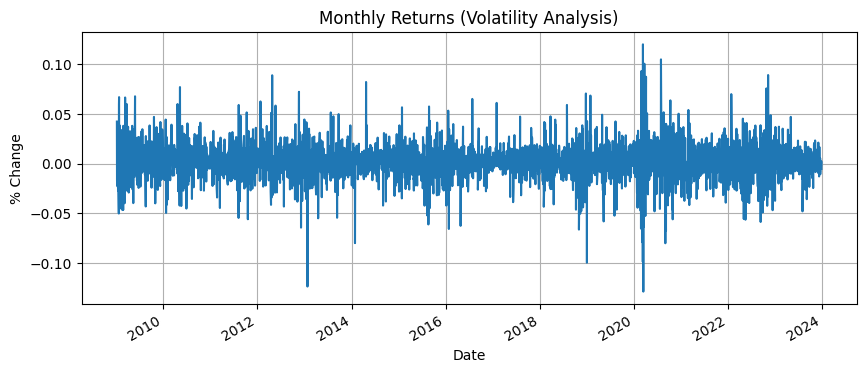

In [24]:
# Summary Statistics
print("--- Summary Statistics ---")
print(aapl_df.describe())



# Calculate Monthly Returns (Percentage Change)
aapl_df['Returns'] = aapl_df['Close'].pct_change()

plt.figure(figsize=(10, 4))
aapl_df['Returns'].plot(title="Monthly Returns (Volatility Analysis)")
plt.ylabel("% Change")
plt.show()

In [25]:
import talib
import pynance as pn
from datetime import datetime, timedelta

# Set visual style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = [12, 7]
plt.rcParams['figure.dpi'] = 100

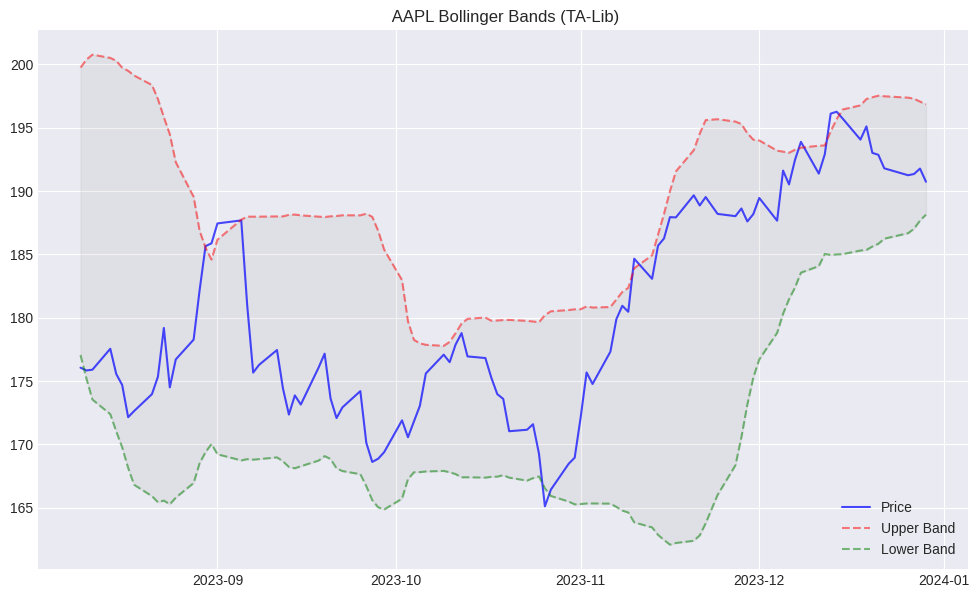

In [28]:
# Calculate Bollinger Bands
aapl_df['upper_band'], aapl_df['middle_band'], aapl_df['lower_band'] = talib.BBANDS(aapl_df['Close'], timeperiod=20, nbdevup=2, nbdevdn=2, matype=0)

fig, ax = plt.subplots()
ax.plot(aapl_df.index[-100:], aapl_df['Close'][-100:], label='Price', color='blue', alpha=0.7)
ax.plot(aapl_df.index[-100:], aapl_df['upper_band'][-100:], label='Upper Band', color='red', linestyle='--', alpha=0.5)
ax.plot(aapl_df.index[-100:], aapl_df['lower_band'][-100:], label='Lower Band', color='green', linestyle='--', alpha=0.5)
ax.fill_between(aapl_df.index[-100:], aapl_df['lower_band'][-100:], aapl_df['upper_band'][-100:], color='gray', alpha=0.1)

ax.set_title(f" AAPL Bollinger Bands (TA-Lib)")
ax.legend()
plt.show()

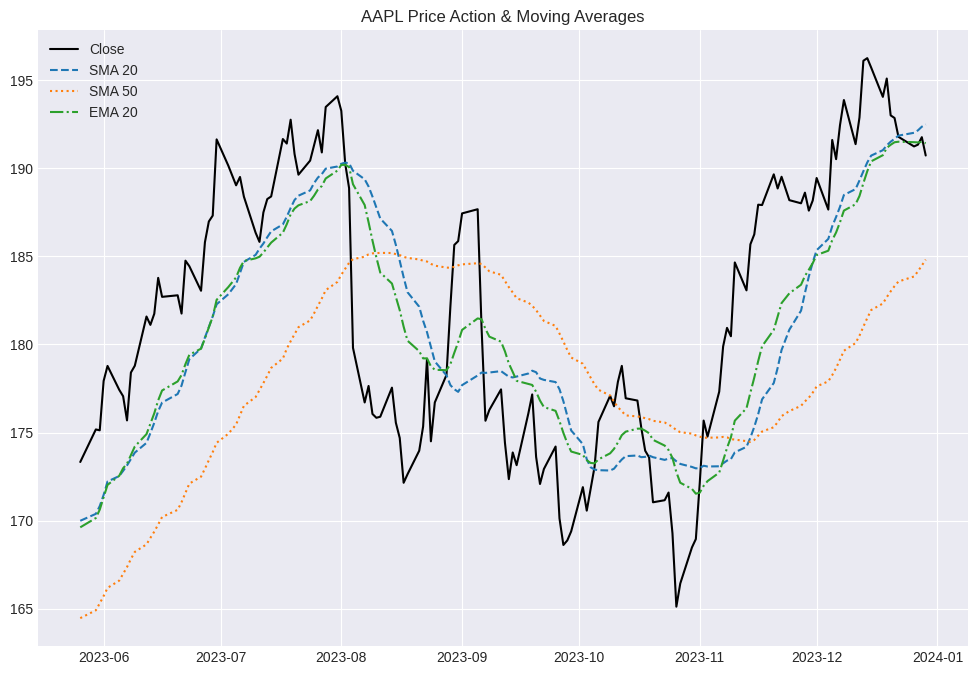

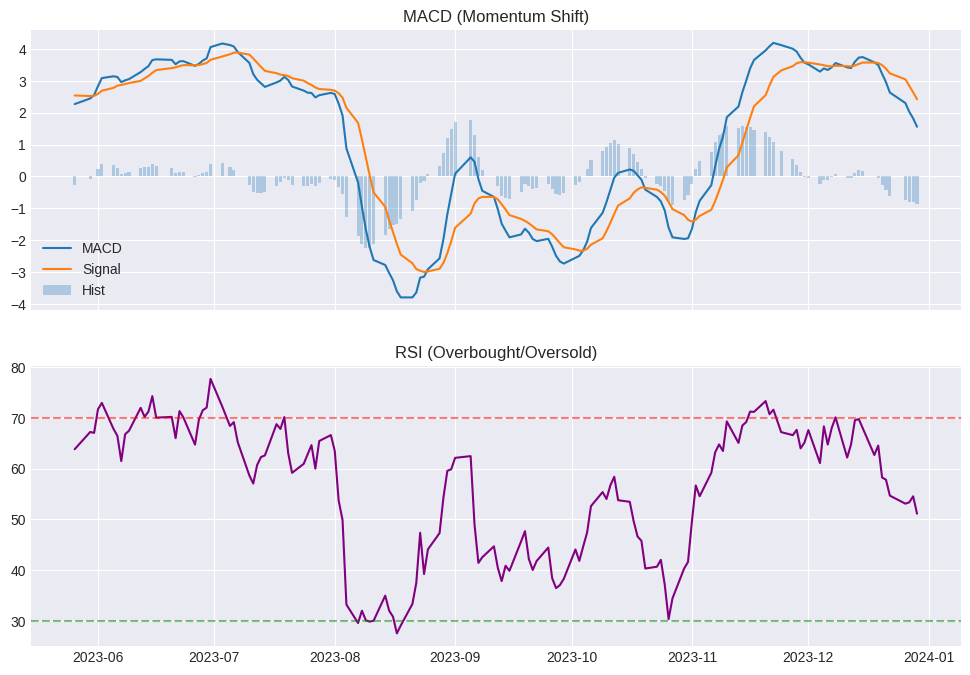

In [29]:
# Calculate Multiple Moving Averages
aapl_df['SMA_20'] = talib.SMA(aapl_df['Close'], timeperiod=20)
aapl_df['SMA_50'] = talib.SMA(aapl_df['Close'], timeperiod=50)
aapl_df['EMA_20'] = talib.EMA(aapl_df['Close'], timeperiod=20)

# Calculate Bollinger Bands
aapl_df['upper_band'], aapl_df['middle_band'], aapl_df['lower_band'] = talib.BBANDS(aapl_df['Close'], timeperiod=20, nbdevup=2, nbdevdn=2, matype=0)

# RSI & MACD
aapl_df['RSI'] = talib.RSI(aapl_df['Close'], timeperiod=14)
aapl_df['macd'], aapl_df['macdsignal'], aapl_df['macdhist'] = talib.MACD(aapl_df['Close'], fastperiod=12, slowperiod=26, signalperiod=9)
# --- VISUALIZATION: Prices overlaid with MAs ---
plt.figure(figsize=(12, 8))
plt.plot(aapl_df.index[-150:], aapl_df['Close'][-150:], label='Close', color='black', linewidth=1.5)
plt.plot(aapl_df.index[-150:], aapl_df['SMA_20'][-150:], label='SMA 20', linestyle='--')
plt.plot(aapl_df.index[-150:], aapl_df['SMA_50'][-150:], label='SMA 50', linestyle=':')
plt.plot(aapl_df.index[-150:], aapl_df['EMA_20'][-150:], label='EMA 20', linestyle='-.')
plt.title(f"AAPL Price Action & Moving Averages")
plt.legend()
plt.show()

# --- VISUALIZATION: RSI and MACD in separate panels ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [1, 1]})
# MACD
ax1.plot(aapl_df.index[-150:], aapl_df['macd'][-150:], label='MACD')
ax1.plot(aapl_df.index[-150:], aapl_df['macdsignal'][-150:], label='Signal')
ax1.bar(aapl_df.index[-150:], aapl_df['macdhist'][-150:], label='Hist', alpha=0.3)
ax1.set_title("MACD (Momentum Shift)")
ax1.legend()

# RSI
ax2.plot(aapl_df.index[-150:], aapl_df['RSI'][-150:], color='purple', label='RSI')
ax2.axhline(70, color='red', linestyle='--', alpha=0.5)
ax2.axhline(30, color='green', linestyle='--', alpha=0.5)
ax2.set_title("RSI (Overbought/Oversold)")
plt.show()